# 6.4 컬러 공간 변환

색은 색각으로 느낀 빛에서 주차수의 차이에 따라 다르게 느껴지는 색상들을 말한다.
컬러 공간이란 색표시계(RGB, CMY, HSV, ...)의 모든 색들을 색 공간에서 3차원 좌표로 표현한 것이다. 그리고 컬러공간이 사용되는 영역이 서로 다르지만 변환 될 수 있다.

## 6.4.2 RGB 컬러 공간
빛의 삼원색(더이상 분해할 수 없는 최소한의 색)인 빨강 초록 파랑을 이용하고 이 원색 조합은 같이 섞은수록 밝아져 가산혼합이라 한다.
그리고 빛을 물리적으로 표현하고 만드는데 사용하는 기본 컬러 공간이다. 하지만 RGB는 인간의 시각과 인지 체계로 정확한 색상을 규정하기는 쉽지 않다. 그러므로 적절하고 다양한 컬러 공간이 필요하다.
그리고 OpenCV에서는 BGR로 반대이므로 주의해야 한다.

## CMY(K) 컬러 공간
인쇄 장비는 종이에 색상을 출력하므로 빛이 아닌 물감의 색을 사용한다. 하지만 물감의 색을 같이 섞을 수록 어두어지므로 감산 혼합이다. 그래서 RGB 공간의 색을 그대로 출력하면 색상이 맞지 않아 색의 삼원색인 청록색(Cyan), 자홍색(Magenta), 노란색(Yellow)을 이용한다. 이 색들은 빛의 삼원색과 보색 관계이며 흰색으로부터 감산되어 색이 만들어진다.
CMY 컬러공간은 색의 삼원색을 축으로 구성하여 입방체를 만들어 3차원 좌표계를 형성한다

그리고 RGB 컬러공간을 변환하려면 서로 보색 관계이므로 아래 식이 성립한다.
C = 255 - R, M = 255 - G, Y = 255 - R

실제로는 많은 색을 섞어보아도 순수한 검은색이 되지 않는다. 그래서 순수한 검은색을 출력하기 위해서 CMY 컬러 모델에 blacK을 추가하여 CMYK 컬러 공간으로 사용한다. 순수한 검정색은 뛰어난 대비를 제공하고 검정 잉크가 컬러보다 비용이 적다.

In [2]:
import numpy as np, cv2, math
import matplotlib.pyplot as plt

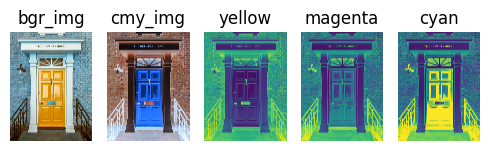

In [3]:
bgr_img = cv2.imread("../images/door.jpg", cv2.IMREAD_COLOR)

white = np.array([255, 255, 255], np.uint8)
cmy_img = white - bgr_img
yellow, magenta, cyan = cv2.split(cmy_img)

titles = ['bgr_img', 'cmy_img', 'yellow', 'magenta', 'cyan']

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(5, 15))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

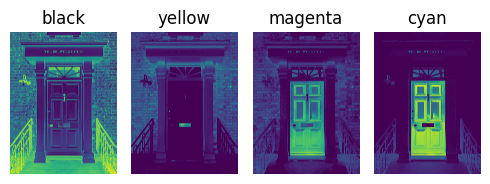

In [4]:
cmy = cv2.split(cmy_img)
black = cv2.min(cmy[0], cv2.min(cmy[1], cmy[2]))
yellow, magenta, cyan = cmy - black

titles = ['black', 'yellow', 'magenta', 'cyan']

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(5, 15))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6.4.4 HSI 컬러 공간
인간이 컬러 영상 정보를 인지하는 방법은 색상(Hue), 채도(Saturation), 명도(Intensity) 라는 세 가지 지각 변수로 분류된다. 
* 색상은 빛이 물체에서 반사되어 나온 색으로 컬러 공간에서 원판의 0 - 360도까지 회전하여 표현한다. 0도 빨간색 .... 300도 다홍색
* 채도는 색의 순수한 정도로 순색에 흰색의 혼합 비율에 따라 0 - 100까지의 값을 가진다. 빨간색은 순색으로 채도가 높아서 100의 값을 가진다. 컬러 공간에서 원판의 중심이 0으로 가장 순도가 낮다.
* 명도는 빛의 밝고 어두운 정도이다. 컬러 공간에서 원뿔의 높이에 해당한다. 가장 위쪽이 흰색 아래쪽이 검은 색이다.

추가로 OpenCV에서는 HSV, HLS 컬러 공간에 대한 변환이 제공된다

In [5]:
def calc_hsi(bgr):
    b, g, r = float(bgr[0]), float(bgr[1]), float(bgr[2]) 
    bgr_sum = b + g + r

    tmp1 = ((r - g) + (r - b)) * .5
    tmp2 = math.sqrt((r - g) * (r - g) + (r - b) * (g - b))
    angle = math.acos(tmp1 / tmp2) * (180 / np.pi) if tmp2 else 0

    h = angle if b <= g else 360 - angle
    s = 1.0 - 3 * min([r, g, b]) / bgr_sum if bgr_sum else 0
    i = bgr_sum / 3

    return (h / 2, s * 255, i)

In [6]:
def bgr2hsi(img):
    hsv = [[calc_hsi(pixel) for pixel in row] for row in img]
    return cv2.convertScaleAbs(np.array(hsv))

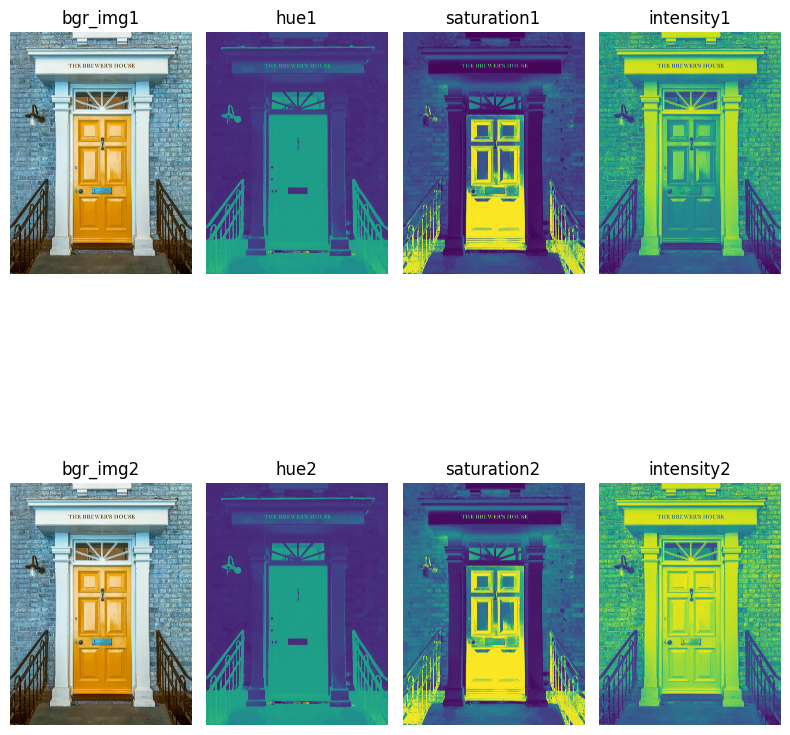

In [11]:
bgr_img1 = cv2.imread("../images/door.jpg", cv2.IMREAD_COLOR)
bgr_img2 = bgr_img

hsi_img = bgr2hsi(bgr_img)
hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
hue1, saturation1, intensity1 = cv2.split(hsi_img)
hue2, saturation2, intensity2 = cv2.split(hsv_img)

titles = ['bgr_img', 'hue', 'saturation', 'intensity', 'bgr_img', 'hue', 'saturation', 'intensity']
    
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(8, 11))

i = 1
for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title + str(i)))
    ax.set_title(title + str(i))
    ax.axis('off')
    if (title == "intensity"):
        i += 1

plt.tight_layout()
plt.show()


## 6.4.5 기타 컬러 공간
YCrCb 컬러공간은 Y가 휘도, Cb, Cr은 색차 성분이다. 인간의 시각은 밝기에 민감하고 색상에는 덜 민감하다. 그래서 Y를 고 해상도로 구성하고 나머지를 상대적으로 저해상도로 구성하고 이렇게 하므로써 인간의 시각에서 화질의 큰 저하 없이 영상 데이터의 용량을 감소할 수 있다.

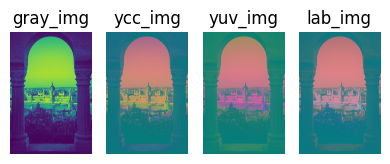

In [12]:
bgr_img = cv2.imread("../images/castle.jpg", cv2.IMREAD_COLOR)

gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
ycc_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2YCrCb)
yuv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2YUV)
lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)

titles = ['gray_img','ycc_img','yuv_img','lab_img']
    
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(4, 12))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()